# Plot raw salinity data at 6 stations for runs 30 and 31

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from vtools.functions.filter import cosine_lanczos
from vtools.data.vtime import days, hours, minutes
import sys
import datetime as datetime    
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib as mpl
import re 
from scipy import signal #for filtering
import cmocean
import matplotlib.dates as mdates
print("Modules imported")

/global/home/users/jennaisrael/.conda/envs/schimpy/lib/python3.7/site-packages/dask/dataframe/utils.py:15: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


Modules imported


In [2]:
def filter_timeseries(tss, cutoff_period=hours(40)):
    #function comes from schimpy metricsplot.py script https://github.com/CADWRDeltaModeling/schimpy/blob/master/schimpy/metricsplot.py
    """ Filter time series

        Parameters
        ----------

        Returns
        -------
        list of vtools.data.timeseries.TimeSeries
            filtered time series
    """

    filtered = []
    ts=tss #try removing the loop for now
    if ts is None:
        filtered.append(None)
    else:
        ts_filtered = cosine_lanczos(ts, cutoff_period=cutoff_period)
        ts_filtered.filtered = 'cosine_lanczos'
    return ts_filtered

In [5]:
def filter_staout(file, timebasis, nstations, path, writeflag):

    # where file is the path to the staout_* file, \n",
    # timebasis is a string of the format \"%m-%d-%y 00:00:00\"\n",
    # which is the run start time which the seconds in the time \n",
    # column of the staout file are in reference to,\n",
    # nstations is the number of stations in the station.in file\n",
    # associated with this run (for the number of columns).\n",
    # path is the file path to write the filtered station_file\n",
    # including the new file's name\n",

    columns = ['time']
    stations_no = [str(i+1) for i in range(nstations)]
    columns = columns + stations_no

    station = pd.read_csv(file, sep='\\s+', names=columns,dtype=np.float32)
    # "\n",
    timedelta = [pd.Timedelta(i, unit = 's') for i in station.time]
    timestamp = pd.Series([pd.to_datetime(timebasis) + i for i in timedelta])

    #added 07/01
    roundtime=timestamp.dt.round(freq='900s')
    station['time'] = roundtime
    station.set_index("time",inplace=True)
    station=station.asfreq('900s')
    
    ######## Below is not robust to getting off by a few seconds use round instead
    #station['time'] = timestamp
    #station.set_index("time",inplace=True)
    # station=station.asfreq('900s')

    ##filter using cosine-lanczos (see above function)\n",
    station_filt = filter_timeseries(station)
    if writeflag > 0:
        station_filt.to_csv(path)
    return station_filt
    #, station
    #return station

In [6]:
timebasis='8-14-2018 00:00:00'
file30='/global/scratch/users/jennaisrael/run_schism/run_30cor/outputs/staout_6'
nstations=596
path30='/global/scratch/users/jennaisrael/run_schism/run_30cor/outputs/staout_6_filt.csv'
run30=filter_staout(file30, timebasis, nstations, path30 , 1)

In [ ]:
# run30_raw.loc[pd.to_datetime("2020-9-28 16:00:00"):pd.to_datetime("2020-9-28 23:00:00"),'1']

In [ ]:
# test=run30_raw.time.dt.round(freq='900s')
# test
# run30_raw.index=test
# run30_raw.drop(columns=['time'])
# run30_raw.loc[pd.to_datetime("2020-9-28 16:00:00"):pd.to_datetime("2020-9-28 23:00:00"),'1']

In [ ]:
# run30_raw.loc[pd.to_datetime("2020-9-28"):pd.to_datetime("2020-10-1"),'1'].plot()

In [7]:
file31='/global/scratch/users/jennaisrael/run_schism/run_31DCP/outputs/staout_6'
nstations=596
path31='/global/scratch/users/jennaisrael/run_schism/run_31DCP/outputs/staout_6_filt.csv'
run31=filter_staout(file31, timebasis, nstations, path31 , 1)

In [ ]:
# run30='/global/scratch/users/jennaisrael/run_schism/run_30cor/outputs/staout_6_filt.csv'
# run31='/global/scratch/users/jennaisrael/run_schism/run_31DCP/outputs/staout_6_filt.csv'

In [8]:
run30

,1,2,3,4,5,6,7,8,9,10,...,587,588,589,590,591,592,593,594,595,596
time,,,,,,,,,,,,,,,,,,,,,
2018-08-14 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-14 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-14 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-14 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-14 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-30 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-30 23:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(0, 0)
(0, 1)
(1, 0)
(1, 1)
(2, 0)
(2, 1)


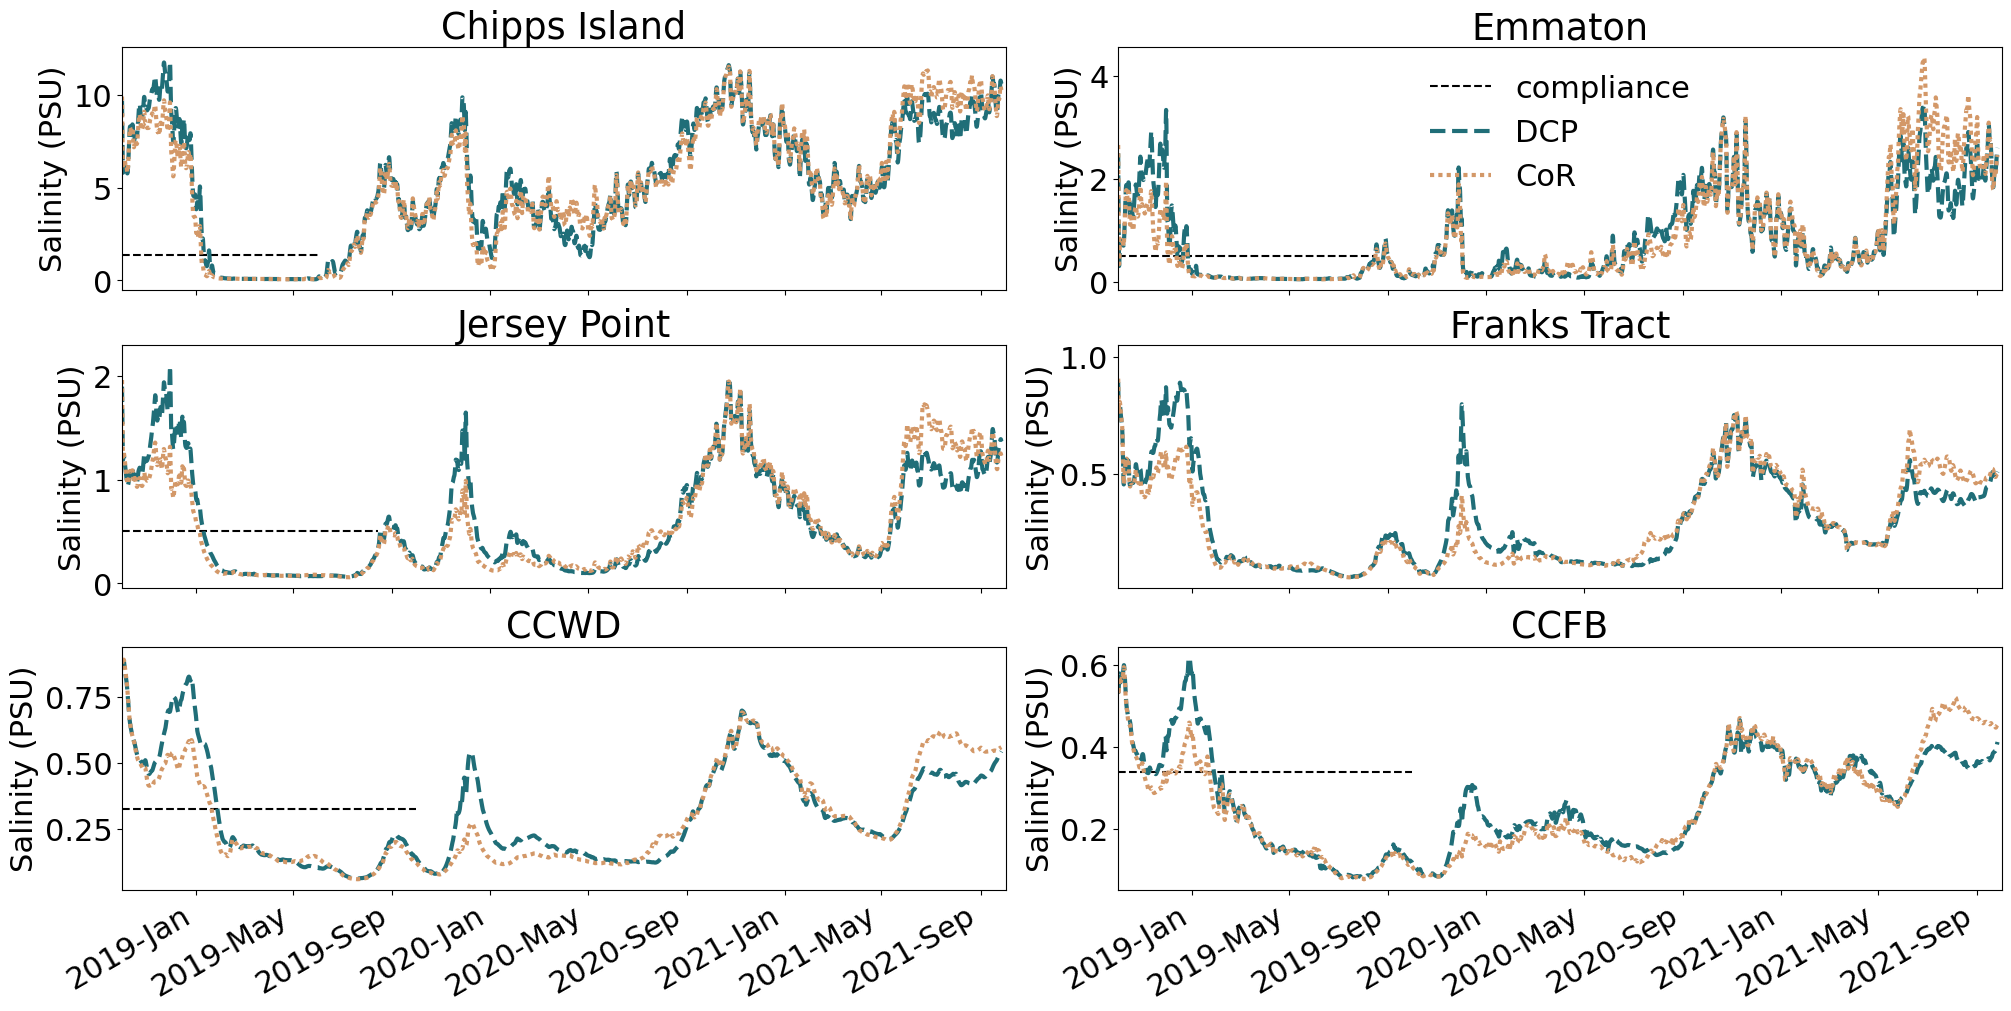

In [10]:
station_indices=[23,9,22,203,105,60]
fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
        ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values3 = run30[str(idx)] # cor
    values2 = run31[str(idx)] # DCP
       
    #ax[s].plot(values1, label = 'Baseline', linewidth=3, alpha =1, color=cmocean.cm.tarn(1/6))
    ax[s].plot(values2, label = 'DCP', linewidth=3, alpha =1,linestyle='--', color=cmocean.cm.tarn(10/12))
    ax[s].plot(values3, label = 'CoR', linewidth=3, alpha =1,linestyle=(0,(1,1)), color=cmocean.cm.tarn(2/6))
    #ax[s].set_title(stations[idx-1]) #this list is zero indexed
    ax[s].set_title(tstring)
    #ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2021-10-02"))
    ax[s].set_ylabel('Salinity (PSU)')
    # Rotates and right-aligns the x labels so they don't crowd each other.

    
#ax.plot(data1.time,np.ones_like(values1)*std,linewidth=2, alpha =0.7,linestyle='--',color='k',label='Compliance')

#leg = ax.legend()
#print(ax)
#ax.set_xlim(data1.time.iloc[52000], data3.time.iloc[-1]) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
#ax[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d-%Y'))
ax[0,1].legend(frameon=False)
ax[2,0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,0].xaxis.get_major_locator()))
ax[2,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,0].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax[2,1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,1].xaxis.get_major_locator()))
ax[2,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,1].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

plt.show()
#fig.savefig('six_stations_timeseries_legend_2_endfeb.png')


In [18]:
run30.loc[pd.to_datetime("2021-9-26 19:00:00"):pd.to_datetime("2021-9-26 21:00:00"),'1']

time
2021-09-26 19:00:00    3.705007
2021-09-26 19:15:00    3.704061
2021-09-26 19:30:00    3.703129
2021-09-26 19:45:00    3.702212
2021-09-26 20:00:00    3.701310
2021-09-26 20:15:00         NaN
2021-09-26 20:30:00         NaN
2021-09-26 20:45:00         NaN
2021-09-26 21:00:00         NaN
Freq: 900S, Name: 1, dtype: float32